# Select PU model features

This notebook will use the training dataset created by notebook `00c` to plot and select features for the PU models.

If training data has been extracted from the source datasets by running the `00c-extract_training_data_global.ipynb` and `00b-extract_grid_data.ipynb` notebooks, set the `use_extracted_data` variable below to `True` to use this dataset instead of the pre-prepared training data from the [Zenodo repository](https://zenodo.org/record/8157691).

## Setup notebook

These cells set some of the important variables and definitions used throughout the notebook, based on the selected config file.

### Config

In [25]:
config_file = "config/.run_config.yml"

In [26]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# =====================
# Filestructure
# =====================

# Base directories
plate_model_dir = pcm.PLATE_MODEL_DIR
points_data_dir = pcm.POINTS_DATA_DIR
output_dir = pcm.OUTPUT_DIR

pcm.create_directories()
pcm.FEATURE_SELECTION_DIR.mkdir(parents=True, exist_ok=True)

# Input data filepaths
regions_filepath = pcm.REGIONS_PATH
training_data_filepath = pcm.TRAINING_DATA_PATH

# Output filepaths
selected_features_filepath = pcm.SELECTED_FEATURES_PATH
selected_features_manifest_filepath = pcm.SELECTED_FEATURES_MANIFEST_PATH

# =====================
# Notebook scope
# =====================

# Gates for determining scope of notebook run (i.e. which feature sets can be selected from)
use_features = pcm.use_features

# If True, use training data extracted in notebook 00b, 00c
# Else, use pre-prepared training data downloaded from Zenodo
use_extracted_data = pcm.use_extracted_data

# If False, skip training the SVM models
create_svm = pcm.config["create_svm"]

# If False, skip training all regional models (PU and SVM)
create_regional_models = pcm.config["create_regional_models"]

# =====================
# Model training parameters
# =====================

# Timespan for plotting
min_time = pcm.config["timespan"]["min"]
max_time = pcm.config["timespan"]["max"]
times = range(min_time, max_time + 1)

# If this parameter is False, perform feature selection using all data for all models
# If True, perform feature selection for each model individually
use_same_features = pcm.config["use_same_features"]

# If this parameter is False, selected features must be specified below
# Otherwise, they will be selected automatically
automatic_feature_selection = pcm.config["automatic_feature_selection"]

# Random seed for reproducibility
random_seed = pcm.config["random_seed"]

# Number of processes to use
n_jobs = pcm.config["n_jobs"]

# Overwrite any existing output files
overwrite = pcm.config["overwrite_output"]

# Control verbosity level of logging output
verbose = pcm.config["verbose"]

### Imports

In [27]:
import warnings
import json

import cartopy.crs as ccrs
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from cartopy.mpl.gridliner import (
    LATITUDE_FORMATTER,
    LONGITUDE_FORMATTER,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pulearn.bagging import BaggingPuClassifier
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import spearmanr
from scipy.stats import entropy as scipy_entropy, differential_entropy
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import IterativeImputer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor

from lib.check_files import check_prepared_data
from lib.misc import (
    format_feature_name,
)
from lib.pu import (
    PU_PARAMS,
    COLUMNS_TO_DROP,
    PRESERVATION_COLUMNS,
    # downsample_unlabelled,
)

# Use figure style template in config directory
plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")

# Suppress FutureWarning for some versions of pandas
pd.set_option('future.no_silent_downcasting', True)

# Suppress FutureWarning for some versions of Scikit-learn
%env PYTHONWARNINGS=ignore

# Suppress some other warnings
warnings.simplefilter("ignore", ConvergenceWarning)

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_16444/1791119109.py:53: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [28]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    print(f"Using prepared training data in {pcm.PREPARED_DATA_DIR}")
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    grid_data_filepath = prep_dir / "grid_data.csv"
    training_filepath = prep_dir / "training_data_global.csv"

figures_dir = pcm.FEATURE_SELECTION_DIR

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_6.0_deg_buffer


### Classifier parameters

In [29]:
# Parameters for models
imputer_params = {
    "random_state": random_seed,
    "add_indicator": False,
}
rf_params = {
    "random_state": random_seed,
    "n_estimators": 50,
    "n_jobs": 1,
}
pu_params = {
    **PU_PARAMS,
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
    "balanced_subsample": True,
}
svm_params = {
    "kernel": "rbf",
    "probability": True,
    "random_state": random_seed,
}

Define model and preprocessing pipeline:

In [30]:
pu_model = BaggingPuClassifier(
    RandomForestClassifier(**rf_params),
    **pu_params
)
preprocessing = make_pipeline(
    # IterativeImputer(**imputer_params),
    RobustScaler(),
    VarianceThreshold(),
)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('robustscaler', ...), ('variancethreshold', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


## Preprocess training data

These cells load and plot the training data.

In [31]:
data = pd.read_csv(training_data_filepath)

data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'plate_transverse_velocity_upper_mantle_abs_max_value (cm/yr)',
       'plate_transverse_velocity_upper_mantle_depth_of_abs_max (km)',
       'temperature_deviation_upper_mantle_ref_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_ref_gradient_delta (K/km/Myr)',
       'temperature_deviation_upper_mantle_depth_integral_delta (K·km/Myr)',
       'temperature_deviation_upper_mantle_min_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_min_delta (km/Myr)',
       'temperature_deviation_upper_mantle_max_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_max_delta (km/Myr)',
       'region'],
      dtype='str', length=121)

### Columns to drop

In [32]:
# ---+ Coordinate columns --------------------------------------------------------

coordinate_columns = {
    "present_lon",
    "present_lat",
    "lon",
    "lat",
    "Cu (Mt)",
    "age (Ma)",
}


# ---+ Metadata columns --------------------------------------------------------

metadata_columns = {
    "region",
    "plate_id",
    "set",
    "source",
    "overriding_plate_id",
    "subducting_plate_ID",
    "trench_plate_ID",
    "arc_segment_length (degrees)",
    "trench_normal_angle (degrees)",
    "distance_from_trench_start (degrees)",
    "distance_from_trench_start (km)",
    "crustal_thickness_n",
    "bracket_infilled",
}


# ---+ Component columns --------------------------------------------------------

# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# # Use orthogonal/parallel velocity vector components
# component_columns |= {
#     "subducting_plate_absolute_velocity (cm/yr)",
#     "convergence_rate (cm/yr)",
#     "trench_velocity (cm/yr)",
# }
# # Drop oceanic crust thickness and convergence rate,
# # only use slab flux (product of the two components)
# component_columns |= {
#     "convergence_rate_orthogonal (cm/yr)",
#     "plate_thickness (m)",
# }
# Drop orthogonal components of mantle/plate velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}


# ---+ Preservation columns --------------------------------------------------------

preservation_columns = {
    "total_precipitation (km)",
    "total_convergence (km)",
    "erosion (m)",
}


# ---+ Degenerate columns --------------------------------------------------------
# Near-constant due to physical absence of the feature at most locations.
# These survive all other drop rules but contain too many NaN to be usable:
#   - parallel zero-crossing: 99.99% NaN (plate-parallel flow never reverses below LAB)
#   - transverse zero-crossing: ~61% NaN (reversal absent at most grid points)
# Either causes spearmanr() to return NaN, making the linkage distance matrix non-finite.

degenerate_columns = {
    "plate_parallel_velocity_lab_relative_zero_crossing_depth (km)",
    "plate_transverse_velocity_lab_relative_zero_crossing_depth (km)",
}

# ---+ Final set for feature selection --------------------------------------------------------

columns_to_drop = coordinate_columns | metadata_columns | component_columns | preservation_columns | degenerate_columns

### Load training data

In [ ]:
data = pd.read_csv(training_data_filepath)

# Remove duplicate points
# Duplicates arise from a one-to-many overriding-plate
# spatial join in combine_point_data() (notebook 00b).
# Deduplication prevents model bias from over-representation of certain locations.
data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits for regional models only.
# The global model *can* train on all deposits, including those outside region polygons.
# But I had another look at the map, and that seems like a bad idea.
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data_regional = data[~data["region"].isin(regions_to_skip)]
data = data[~data["region"].isin(regions_to_skip)]


cleaned = data.drop(
    columns=list(columns_to_drop),
    errors="ignore",
)

columns_with_nans = cleaned.columns[cleaned.isna().any()].tolist()
if columns_with_nans:
    print("Warning: The following columns contain NaN values:")
    for col in columns_with_nans:
        nan_percentage = cleaned[col].isna().mean() * 100
        print(f" - {col}: {nan_percentage:.2f}% NaN")
    print("Dropping...")
    cleaned = cleaned.drop(columns=columns_with_nans)
    print("Dropped columns with NaN values.\n\n")

print("Training data summary (global):")
print(data.groupby(["region", "label"]).size())
print("\nOverall class distribution (global):")
print(data.groupby(["label"]).size())

Training data summary (global):
region          label     
East Asia       negative         7
                positive       140
                unlabelled    5223
North America   negative        51
                positive       283
                unlabelled    6020
Other           negative        70
                positive         2
                unlabelled    4708
South America   negative       641
                positive       160
                unlabelled    6081
Southeast Asia  negative         2
                positive       123
                unlabelled    3927
Tethys          negative         5
                positive       281
                unlabelled    4831
dtype: int64

Overall class distribution (global):
label
negative        776
positive        989
unlabelled    30790
dtype: int64


### Wrangle training data

In [34]:
# Wrangle the training data to the required format
train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
x_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

### Plot deposit locations

This cell plots the locations of the deposits in the training dataset, saving the image in the `output_dir` directory.

2026-05-24,18:21:58 - pmm - WARNING - The layer(COBs) was not found in model(zahirovic2022).
2026-05-24,18:21:58 - pmm - WARNING - The layer(COBs) does not exist in model(zahirovic2022).


/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/op

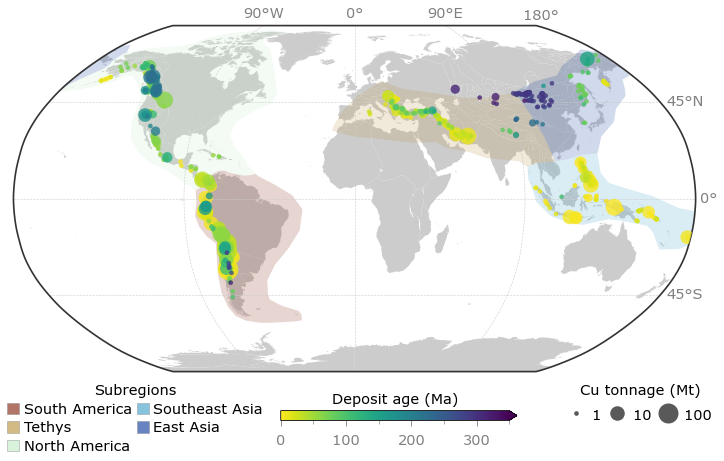

In [35]:
import cmcrameri.cm as cmc
import geopandas as gpd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from lib.plate_models import get_plot_topologies
output_deposits = figures_dir / "deposits"


# --- Parameters ---
AGE_RANGE   = (0, 350)     # Ma, colormap range for deposit age
CMAP        = cm.viridis_r # colormap for deposit age
REGION_CMAP = cmc.roma     # colormap for region polygon fill colours
CU_RANGE    = (1, 150)     # Mt, Cu tonnage range for marker size scaling
S_DEFAULT   = 5            # marker size (pt²) for deposits without Cu tonnage data
S_RANGE     = (5, 100)      # (min, max) pt² for Cu-scaled markers
LAND_COLOR = "#CCCCCC"
CONTINENTS_COLOR  = "#FFFFFF"
OCEAN_COLOR = "#FFFFFF"

deposits = data[data["label"] == "positive"]

TW       = 150 / 25.4
PROJ     = ccrs.Robinson()
DATA_CRS = ccrs.PlateCarree()
_ts      = plt.rcParams["xtick.labelsize"]

age_norm = mpl.colors.Normalize(*AGE_RANGE)
age_sm   = mpl.cm.ScalarMappable(norm=age_norm, cmap=CMAP);  age_sm.set_array([])

# Marker size: log-scaled by Cu (Mt); NaN/zero → S_DEFAULT
cu     = deposits["Cu (Mt)"]
has_cu = cu.notna() & (cu > 0)
t      = (np.log10(cu.clip(*CU_RANGE)) - np.log10(CU_RANGE[0])) / (np.log10(CU_RANGE[1]) - np.log10(CU_RANGE[0]))
s      = np.where(has_cu, S_RANGE[0] + (S_RANGE[1] - S_RANGE[0]) * t, S_DEFAULT)

# Region colours: one unique colour per region name from REGION_CMAP
regions_gdf    = gpd.read_file(regions_filepath)
unique_regions = list(dict.fromkeys(regions_gdf["region"]))
n_r            = len(unique_regions)
_rgbmap        = {name: REGION_CMAP(i / max(n_r - 1, 1)) for i, name in enumerate(unique_regions)}
row_colors     = [_rgbmap[r] for r in regions_gdf["region"]]

# Figure
fig = plt.figure(figsize=(TW, TW * 0.62))
fig.subplots_adjust(left=0.01, right=0.89, top=0.93, bottom=0.30)
ax  = fig.add_subplot(1, 1, 1, projection=PROJ)
ax.set_global()
ax.set_facecolor(OCEAN_COLOR)

# Geography — GPlately plate reconstruction at 0 Ma
_use_provided = pcm.config["plate_model"]["use_provided_plate_model"]
_model_name   = None if _use_provided else pcm.config["plate_model"]["plate_model_name"]
gplot = get_plot_topologies(model_name=_model_name, model_dir=plate_model_dir, time=0)
gplot.plot_continents(ax, color="none", facecolor=CONTINENTS_COLOR, zorder=0)
gplot.plot_coastlines(ax, color="none", linewidth=0.2, facecolor=LAND_COLOR, zorder=1)

# Study regions — each unique region in a distinct colour from REGION_CMAP
for geom, color in zip(regions_gdf.geometry, row_colors):
    ax.add_geometries([geom], crs=DATA_CRS, facecolor=color, edgecolor="none", alpha=0.18, zorder=2)

# Deposits — uniform marker, Cu-scaled size, age-coloured
ax.scatter(
    deposits["present_lon"], deposits["present_lat"],
    c=deposits["age (Ma)"], norm=age_norm, cmap=CMAP,
    s=s, marker="o", alpha=0.80, linewidths=0,
    transform=DATA_CRS, zorder=3,
)

# Frame + gridlines (xpadding/ypadding=2 keeps labels close to frame)
ax.spines["geo"].set_linewidth(0.8)
ax.spines["geo"].set_edgecolor("0.2")
gl = ax.gridlines(
    crs=DATA_CRS,
    draw_labels={"top": "x", "right": "y", "bottom": False, "left": False},
    linewidth=0.3, color="#cccccc", linestyle="--", alpha=0.9, zorder=4,
)
gl.xlocator      = mticker.FixedLocator([-90, 0, 90, 180])
gl.ylocator      = mticker.FixedLocator([-45, 0, 45])
gl.xlabel_style  = {"size": _ts, "color": "0.5"}
gl.ylabel_style  = {"size": _ts, "color": "0.5"}
gl.rotate_labels = False
gl.xpadding      = 2
gl.ypadding      = 2

# ax.set_title("Porphyry Cu deposits", fontsize=plt.rcParams["axes.titlesize"], pad=14, loc="left")

# --- Bottom items layout ---
# Three items [regions legend] [age colorbar] [size legend] occupy FIG_SPAN of figure width.
# GAP is the space between adjacent items (both in figure coordinates).
FIG_SPAN = 0.90
GAP      = 0.05
ITEM_W   = (FIG_SPAN - 2 * GAP) / 3   # ≈ 0.267 of figure width per item
X0       = (1.0 - FIG_SPAN) / 2       # left edge of first item = 0.05

pos      = ax.get_position()
BAND_TOP = pos.y0 - 0.025             # top of the legends/colorbar band
offset   = 0.015                       # vertical offset of legends/colorbar from top of band

x_reg = X0
x_cb  = X0 + ITEM_W + GAP
x_sz  = X0 + 2 * (ITEM_W + GAP)

# Colorbar — vertically centered within estimated 2-row legend height (~0.10 fig coords)
CB_H = 0.018
CB_Y = BAND_TOP - 0.055 - CB_H / 2
cax  = fig.add_axes([x_cb, CB_Y, ITEM_W, CB_H])
cbar = fig.colorbar(age_sm, cax=cax, orientation="horizontal", extend="max",
                    extendfrac=CB_H / ITEM_W / 2)
cbar.set_label("Deposit age (Ma)", fontsize=_ts, color="black", labelpad=3)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(2))
cbar.ax.tick_params(which="major", labelsize=_ts, color="0.5", labelcolor="0.5", width=0.4, length=3, direction="out")
cbar.ax.tick_params(which="minor", color="0.5", width=0.3, length=1.8, direction="out")
cbar.outline.set_linewidth(0.4)
cbar.outline.set_edgecolor("0.0")

# Region legend — 2 rows × 3 cols, one patch per unique region
region_handles = [
    Patch(facecolor=_rgbmap[name], edgecolor="0.5", linewidth=0.3, alpha=0.6, label=name)
    for name in unique_regions
]
fig.legend(
    handles=region_handles,
    title="Subregions",
    loc="upper left",
    bbox_to_anchor=(x_reg, BAND_TOP + offset),
    bbox_transform=fig.transFigure,
    ncols=2,
    fontsize=_ts,
    title_fontsize=_ts,
    frameon=False,
    handlelength=0.8,
    handleheight=0.8,
    handletextpad=0.3,
    columnspacing=0.4,
    labelspacing=0.3,
    borderpad=0,
)

# Size legend — 1 row × 3 cols; powers of 10 within CU_RANGE
# markersize for Line2D is diameter in pt; scale to match relative scatter sizes
_cu_refs = [10**i for i in range(
    int(np.ceil(np.log10(max(CU_RANGE[0], 1)))),
    int(np.floor(np.log10(CU_RANGE[1]))) + 1,
)]
_t_refs  = [(np.log10(v) - np.log10(CU_RANGE[0])) / (np.log10(CU_RANGE[1]) - np.log10(CU_RANGE[0]))
            for v in _cu_refs]
_sz_refs = [S_RANGE[0] + (S_RANGE[1] - S_RANGE[0]) * t_ for t_ in _t_refs]
size_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="0.35", markeredgewidth=0,
           markersize=np.sqrt(sz) * 1.0, label=f"{v:g}")
    for v, sz in zip(_cu_refs, _sz_refs)
]
fig.legend(
    handles=size_handles,
    title="Cu tonnage (Mt)",
    loc="upper left",
    bbox_to_anchor=(x_sz, BAND_TOP + offset),
    bbox_transform=fig.transFigure,
    ncols=len(_cu_refs),
    # ncols=1,
    fontsize=_ts,
    title_fontsize=_ts,
    frameon=False,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.6,
    columnspacing=0.6,
    labelspacing=0.6,
    borderpad=0,
)

for ext in (".pdf", ".png"):
    fig.savefig(output_deposits.with_suffix(ext), dpi=400, bbox_inches="tight")
fig.show()

## Select global features

### Feature analysis

#### Feature correlation

We consider features with a Spearman's correlation $|r| \geq 0.75$ to be highly correlated and consider removing them.

In [36]:
cutoff_value = 0.75
cluster_threshold = 1 - cutoff_value

Z = linkage(
    clone(preprocessing).fit_transform(x_pu).T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(x_pu.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

In [ ]:
def plot_dendrogram(Z, clusters, feature_names, title="", filename=None):
    fig_dims = (5.91, max(3.65, len(feature_names) * 0.17))
    fig, ax = plt.subplots(figsize=fig_dims)
    dendro = dendrogram(
        Z,
        orientation="right",
        labels=[format_feature_name(i, bold=True) for i in feature_names],
        ax=ax,
        color_threshold=cluster_threshold,
    )
    ax.axvline(cluster_threshold, linestyle="dashed", color="red", zorder=10)
    ax.annotate(
        f"{cutoff_value:.2f}",
        xy=(cluster_threshold, 0),
        xycoords=("data", "axes fraction"),
        xytext=(cluster_threshold, -2.0 / len(feature_names)),
        textcoords=("data", "axes fraction"),
        ha="center", va="top",
        color="red",
        fontsize=plt.rcParams.get("xtick.labelsize", 8),
        arrowprops=dict(arrowstyle="-|>", color="red", lw=0.8, mutation_scale=8),
        annotation_clip=False,
    )
    ax.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax.set_xticks(ax.get_xticks(), [f"{1 - i:0.1f}" for i in ax.get_xticks()])
    ax.set_xlabel(r"Spearman's $|r|$")
    for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
        i.set_color(j)
        i.set_fontweight("bold")
        i.set_fontsize(8)
    if title:
        ax.set_title(title)
    if filename is not None:
        for ext in (".pdf", ".png"):
            fig.savefig(f"{filename}{ext}", bbox_inches="tight")
    return dendro


def plot_combined(Z, clusters, mi_series, feature_names, title="", filename=None, feature_set_map=None):
    fig_dims = (5.91, max(3.65, len(feature_names) * 0.17))
    fig, (ax_mi, ax_dendro) = plt.subplots(
        1, 2,
        figsize=fig_dims,
        sharey=True,
        gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1},
    )
    _dendro = dendrogram(
        Z,
        orientation="right",
        labels=[format_feature_name(i, bold=True) for i in feature_names],
        ax=ax_dendro,
        color_threshold=cluster_threshold,
    )
    ax_dendro.axvline(cluster_threshold, linestyle="dashed", color="red", zorder=10)
    ax_dendro.annotate(
        f"{cutoff_value:.2f}",
        xy=(cluster_threshold, 0),
        xycoords=("data", "axes fraction"),
        xytext=(cluster_threshold, -2.0 / len(feature_names)),
        textcoords=("data", "axes fraction"),
        ha="center", va="top",
        color="red",
        fontsize=plt.rcParams.get("xtick.labelsize", 8),
        arrowprops=dict(arrowstyle="-|>", color="red", lw=0.8, mutation_scale=8),
        annotation_clip=False,
    )
    ax_dendro.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax_dendro.set_xlim(0, 1)
    ax_dendro.set_xticks(ax_dendro.get_xticks(), [f"{1 - i:0.1f}" for i in ax_dendro.get_xticks()])
    ax_dendro.set_xlabel(r"Spearman's $|r|$")
    ax_dendro.tick_params(labelleft=False, left=False)
    if title:
        ax_dendro.set_title(title)

    leaf_colours = _dendro["leaves_color_list"]
    ordered_features = [feature_names[i] for i in _dendro["leaves"]]
    ordered_mi = [mi_series[f] for f in ordered_features]

    if feature_set_map is not None:
        palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        set_colours = {name: palette[i % len(palette)] for i, name in enumerate(feature_set_map)}
        feat_to_colour = {f: set_colours[name] for name, feats in feature_set_map.items() for f in feats}
        leaf_colours = [feat_to_colour.get(f, "#aaaaaa") for f in ordered_features]

    y_pos = np.arange(len(ordered_features)) * 10 + 5
    mi_upper = np.ceil(max(ordered_mi) * 10) / 10
    ax_mi.barh(y_pos, ordered_mi, height=9, color=leaf_colours, edgecolor="none")
    ax_mi.set_xlim(0, mi_upper)
    ax_mi.set_xlabel("Mutual information\nwith deposit label")
    for label, color in zip(ax_mi.get_ymajorticklabels(), leaf_colours):
        label.set_color(color)
        label.set_fontweight("bold")
        label.set_fontsize(7)
    ax_mi.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax_mi.set_axisbelow(True)

    if feature_set_map is not None:
        legend_handles = [
            Patch(color=set_colours[name], label=name)
            for name in feature_set_map
        ]
        ax_mi.legend(handles=legend_handles,
                     loc="upper right",
                     bbox_to_anchor=(0, -1.0 / len(feature_names)),
                     bbox_transform=ax_mi.transAxes,
                     fontsize=6, framealpha=0.8, handlelength=1)

    if filename is not None:
        for ext in (".pdf", ".png"):
            fig.savefig(f"{filename}{ext}", bbox_inches="tight")

The following groups of features are highly correlated:

In [38]:
for cluster_id in sorted(clusters.keys()):
    cluster_features = clusters[cluster_id]
    print(f"Cluster #{cluster_id}:")
    for feature in cluster_features:
        print(f"  - {feature}")

Cluster #1:
  - temperature_deviation_upper_mantle_ref_value (K)
  - tangential_speed_upper_mantle_ref_value (cm/yr)
Cluster #2:
  - radial_velocity_upper_mantle_ref_value (cm/yr)
Cluster #3:
  - temperature_deviation_upper_mantle_ref_value_delta (K/Myr)
Cluster #4:
  - subducting_plate_absolute_velocity_parallel (cm/yr)
  - convergence_rate_parallel (cm/yr)
  - subducting_plate_absolute_obliquity (degrees)
  - convergence_obliquity (degrees)
Cluster #5:
  - trench_velocity_obliquity (degrees)
Cluster #6:
  - trench_velocity_parallel (cm/yr)
Cluster #7:
  - plate_thickness (m)
  - seafloor_age (Ma)
Cluster #8:
  - slab_dip (degrees)
  - arc_trench_distance (km)
Cluster #9:
  - trench_velocity_orthogonal (cm/yr)
  - trench_velocity (cm/yr)
Cluster #10:
  - convergence_rate (cm/yr)
  - convergence_rate_orthogonal (cm/yr)
  - subducting_plate_absolute_velocity (cm/yr)
  - subducting_plate_absolute_velocity_orthogonal (cm/yr)
  - slab_flux (m^2/yr)
Cluster #11:
  - seafloor_spreading_rate 

#### Cutoff threshold

We can also visualise the number of features as a function of the Spearman's $|r|$ cutoff threshold:

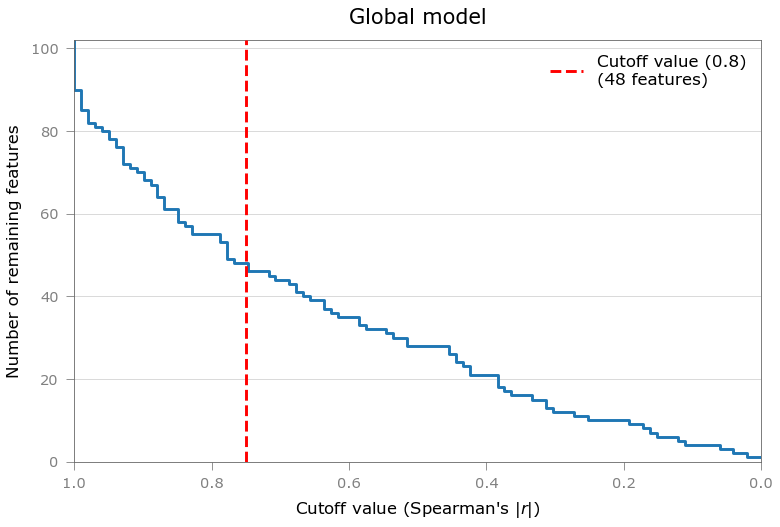

In [39]:
cutoff_nfeatures_filename = figures_dir / "cutoff_nfeatures"

thresh_vals = np.linspace(0, 1, 100)
thresh_clusters = np.array([
    len(np.unique(fcluster(Z, 1 - t, criterion="distance")))
    for t in thresh_vals
])

fig_dims = (5.91, 3.65)
fig, ax = plt.subplots(figsize=fig_dims)
ax.step(thresh_vals, thresh_clusters, where="post")
ax.axvline(
    cutoff_value,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} features)",
)
ax.set_xlim(thresh_vals.max(), thresh_vals.min())
ax.set_ylim(0, None)
ax.grid(linestyle="-", color="lightgrey", axis="y")
ax.legend(loc="best")
ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
ax.set_ylabel("Number of remaining features")
ax.set_title("Global model")

for ext in (".pdf", ".png"):
    fig.savefig(f"{cutoff_nfeatures_filename}{ext}", bbox_inches="tight")

#### Mutual information

Another useful metric is mutual information, which tells us how much each feature has in common with the distribution of positive labels:

In [40]:
# Compute MI scores (sklearn uses nats, consistent with scipy default)
X_preprocessed = clone(preprocessing).fit_transform(x_pu)
mi_scores = mutual_info_classif(
    X_preprocessed,
    y_pu,
    random_state=random_seed,
)

# Normalise by target entropy so axis is bounded [0, 1]
# MI / H(Y) represents fraction of target uncertainty explained by each feature
p = y_pu.mean()
target_entropy = scipy_entropy([p, 1 - p])
mi_normalised = mi_scores / target_entropy
mi_series = pd.Series(mi_normalised, index=x_pu.columns)

#### Combined plot

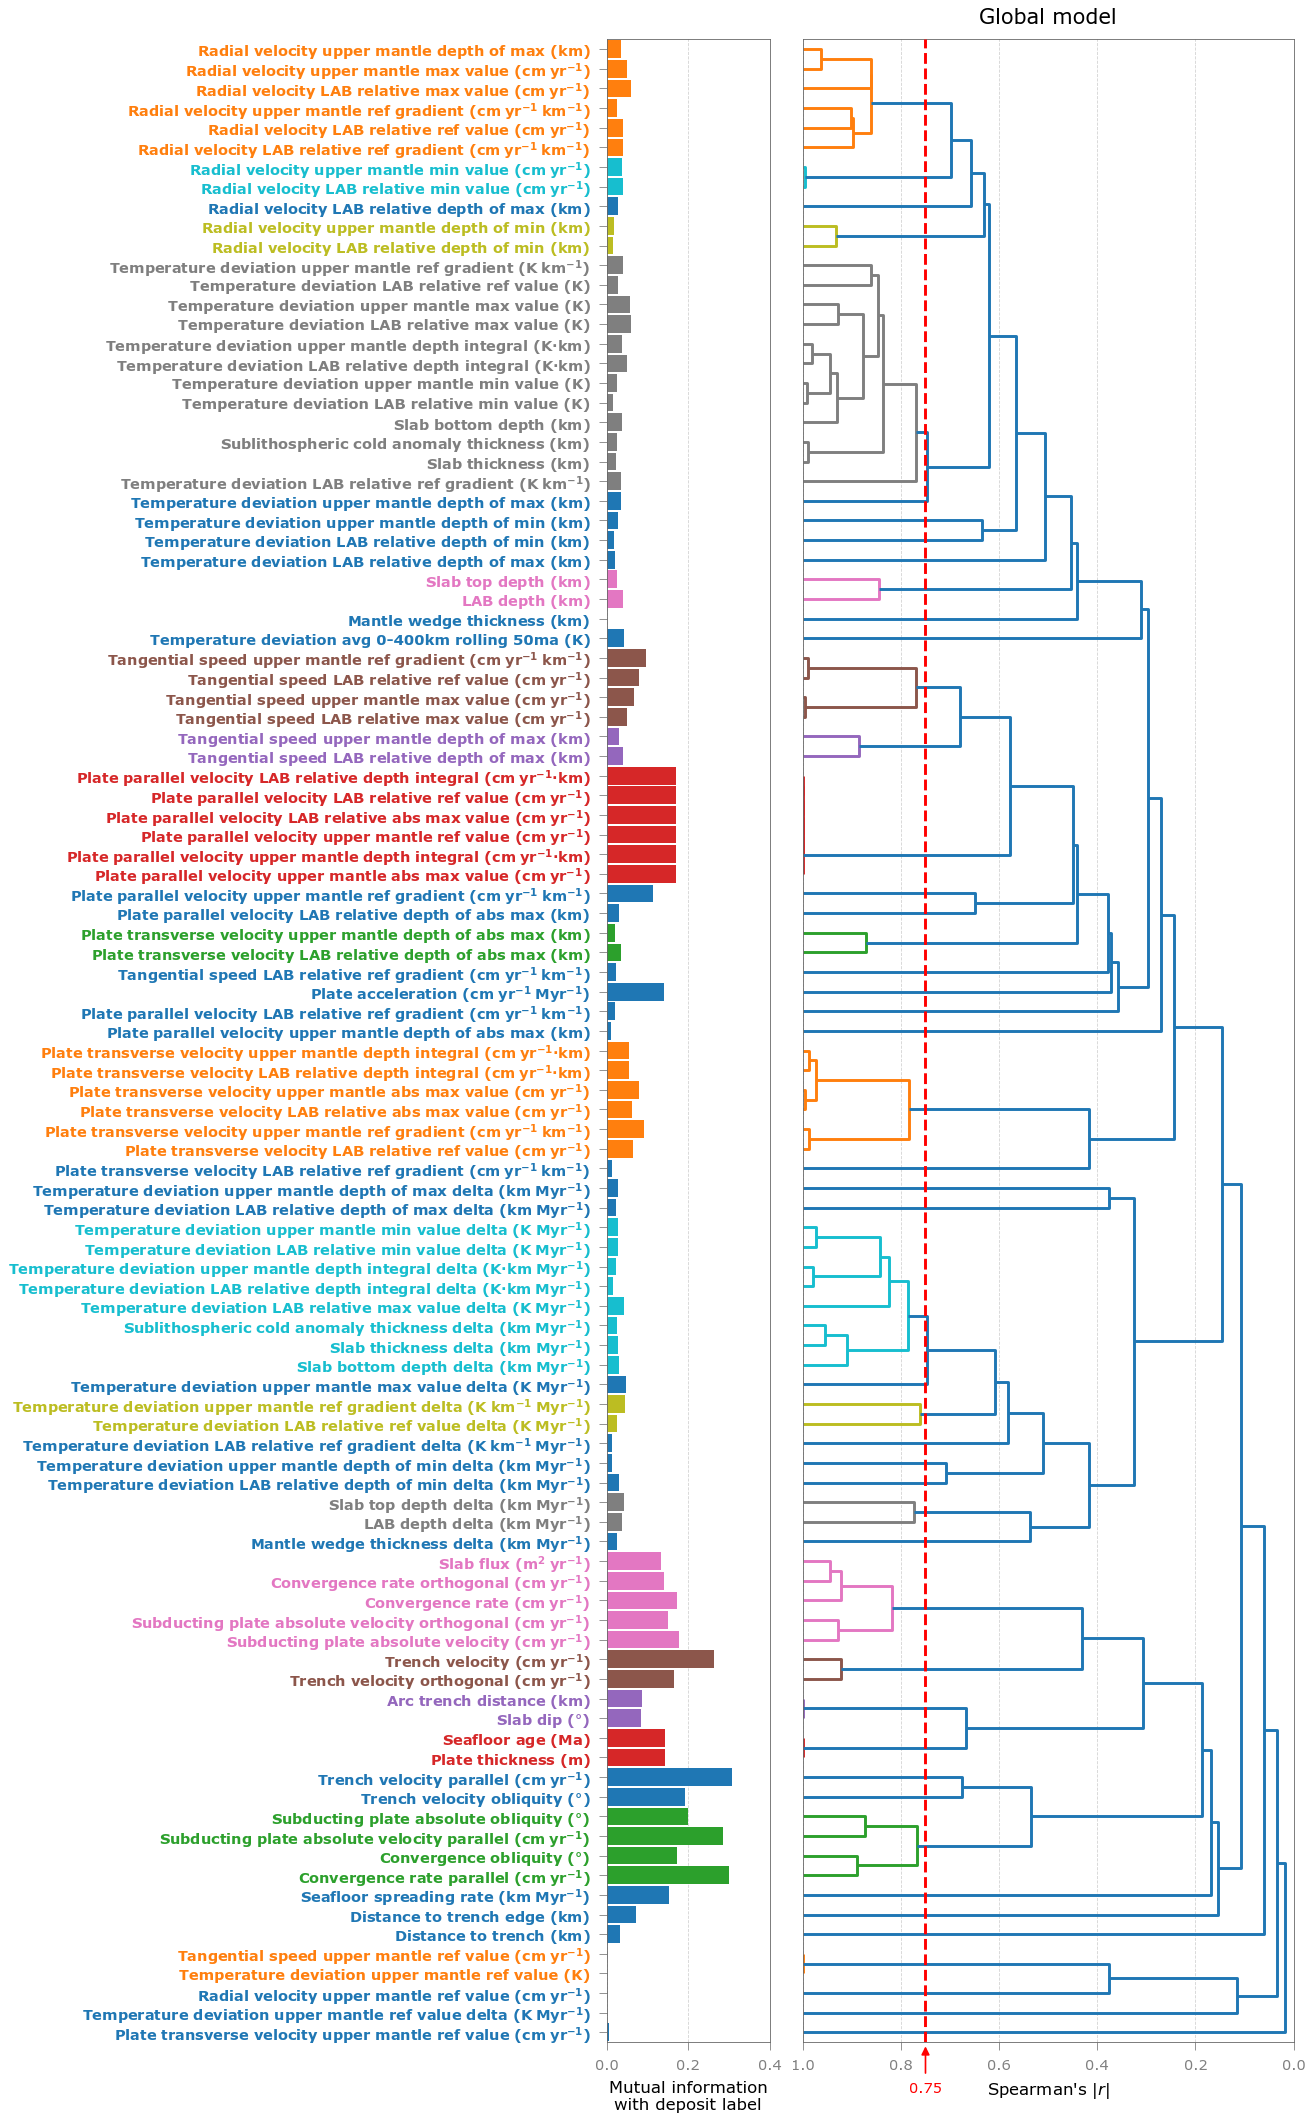

In [45]:
combined_filename = figures_dir / "mi_dendrogram"

plot_combined(Z, clusters, mi_series, x_pu.columns, title="Global model", filename=combined_filename)

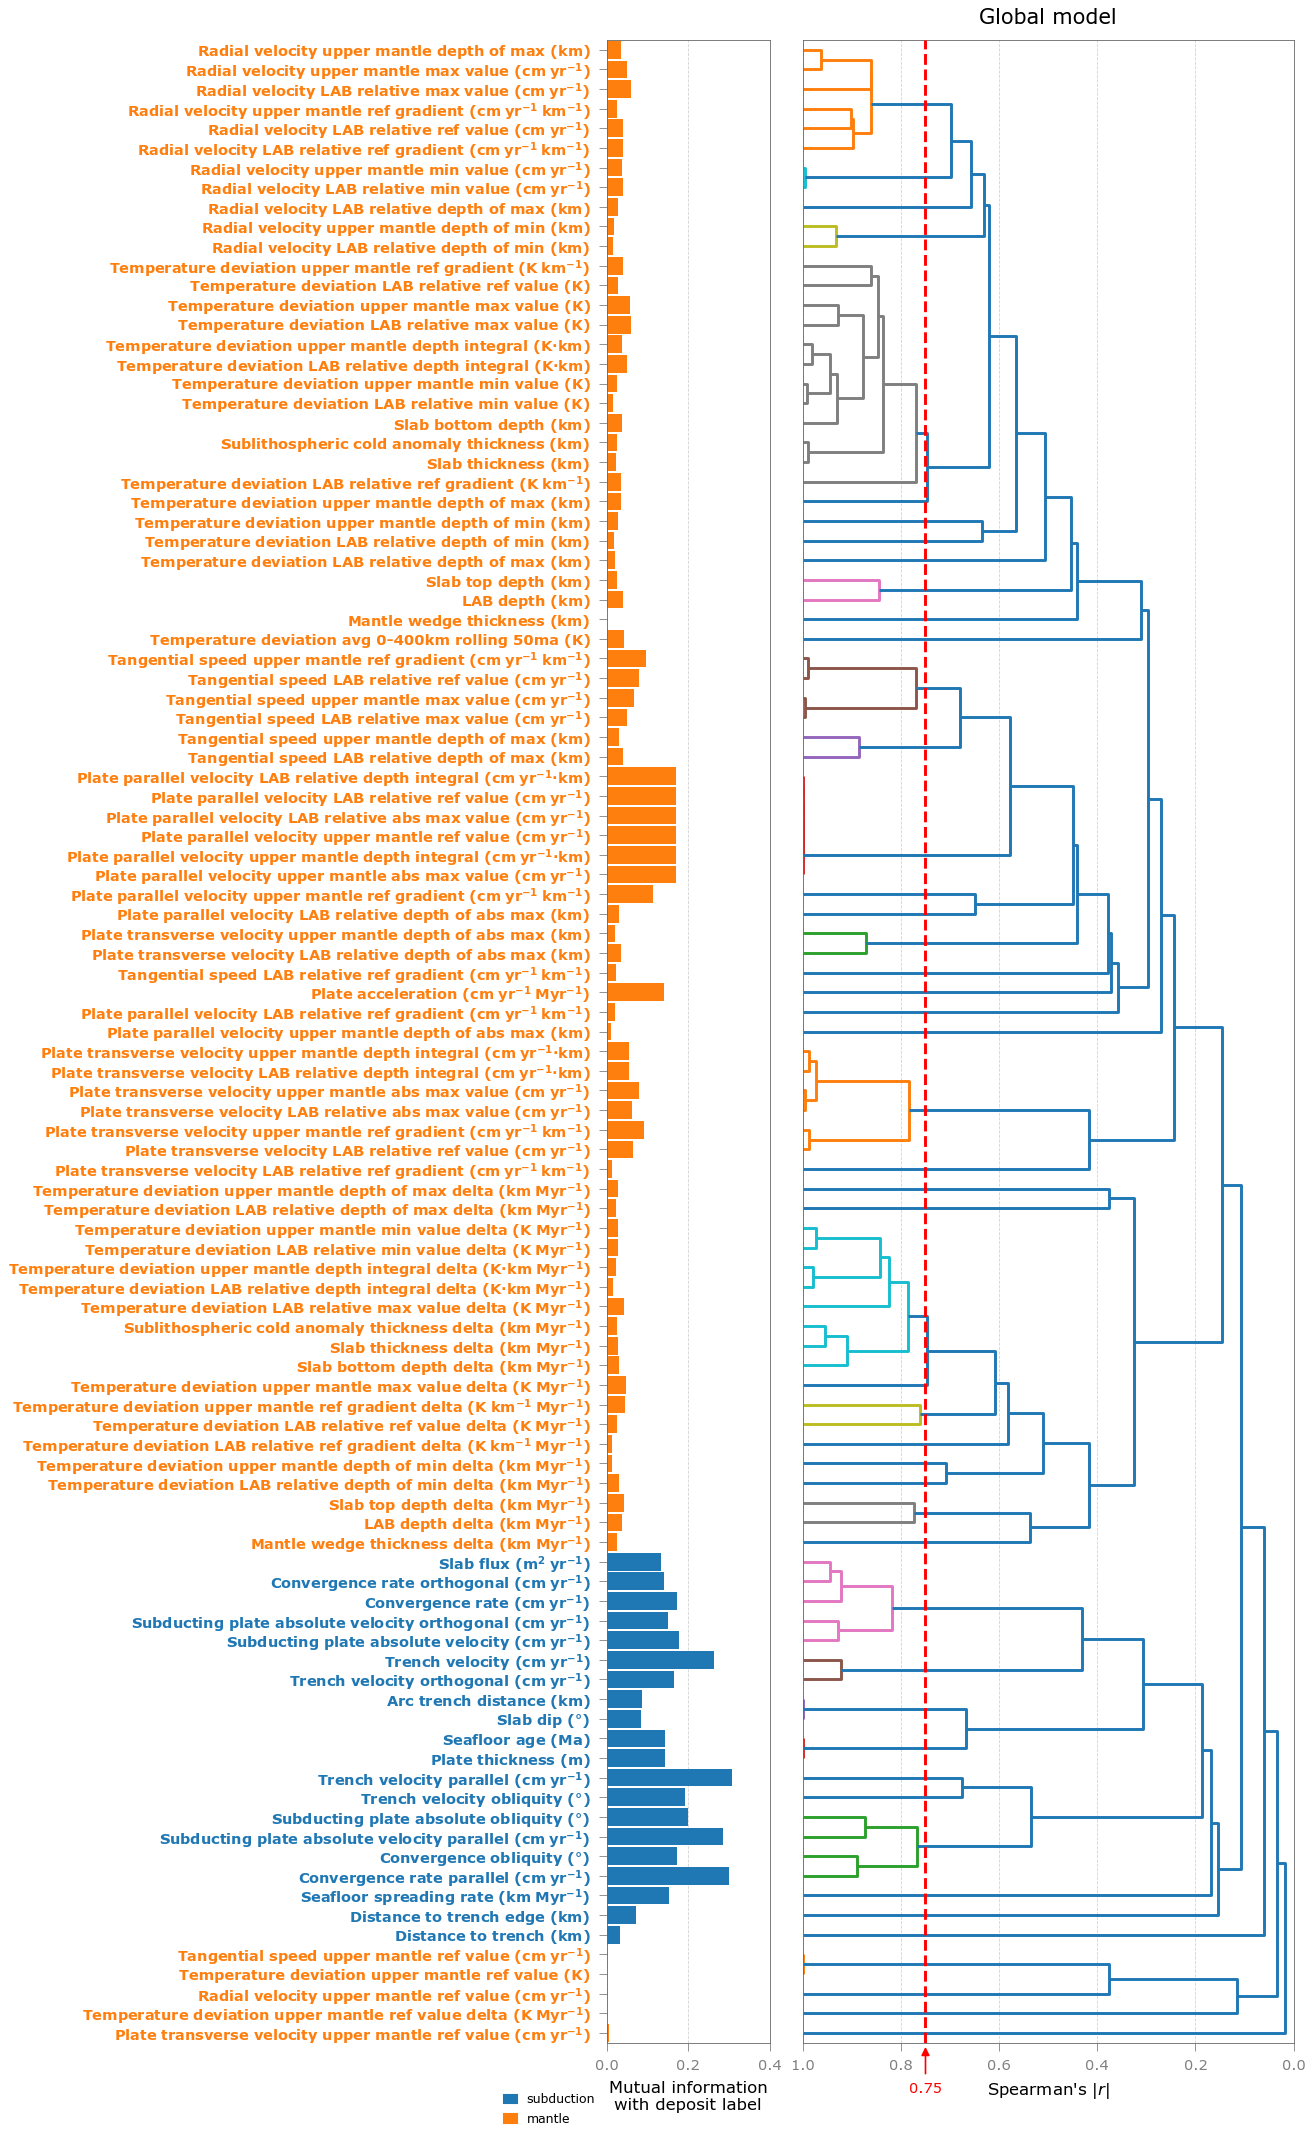

In [46]:
with open(pcm.FEATURES_MANIFEST_PATH) as f:
    global_manifest = json.load(f)

filtered_manifest = {k: v for k, v in global_manifest.items() if k in pcm.active_feature_sets}

plot_combined(Z, clusters, mi_series, x_pu.columns, title="Global model",
              filename=figures_dir / "mi_dendrogram_feature_sets",
              feature_set_map=filtered_manifest)

#### Variance inflation factor

As a sanity-check, we take a look at the whole data set to see which features can be constructed as linear combinations of other features. This step is less useful when using a tree-based classifier like a random forest (as we do here), but it is still interesting. If a feature's VIF is greater than five, it's too collinear and not worth keeping.

/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide


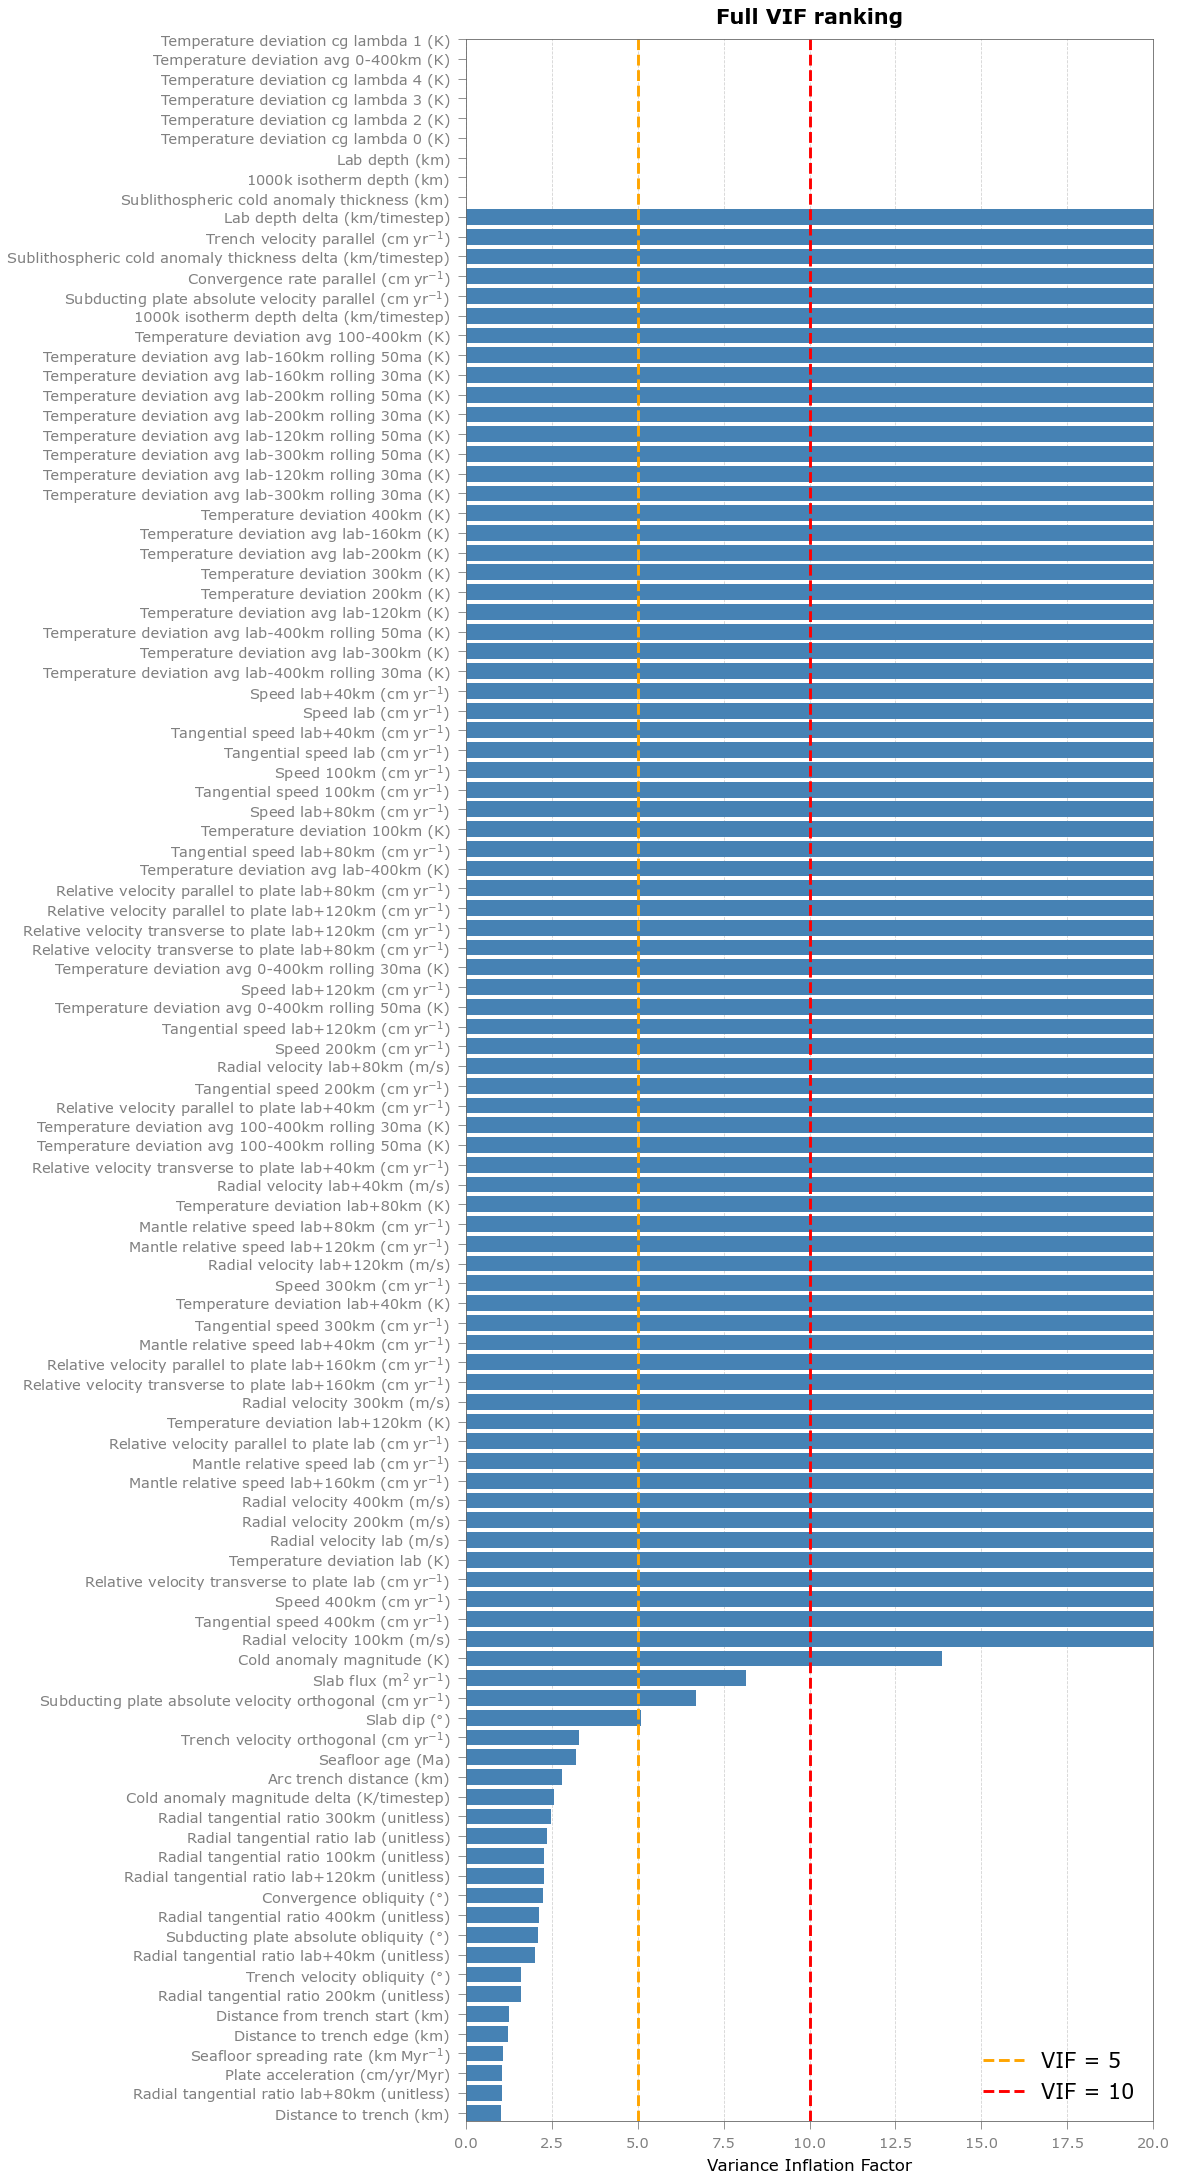

In [ ]:


X_all = pd.DataFrame(
    clone(preprocessing).fit_transform(x_pu),
    columns=x_pu.columns,
)

# VIF within each cluster (undefined/trivially 1 for singletons)
vif_records = [
    {"feature": col, "VIF": variance_inflation_factor(X_all.values, i)}
    for i, col in enumerate(X_all.columns)
]

vif_df = (
    pd.DataFrame(vif_records)
    .sort_values(["VIF"], ascending=[True])
    .reset_index(drop=True)
)

# Plot
vif_filename = figures_dir / "full_vif"

fig, ax = plt.subplots(figsize=(5.91, max(4, len(vif_df) * 0.17)))
ax.barh(
    range(len(vif_df)),
    vif_df["VIF"],
    color="steelblue",
    edgecolor="none",
)
ax.axvline(5, linestyle="dashed", color="orange", label="VIF = 5")
ax.axvline(10, linestyle="dashed", color="red", label="VIF = 10")
ax.set_yticks(range(len(vif_df)))
ax.set_yticklabels([format_feature_name(f) for f in vif_df["feature"]])
ax.set_xlabel("Variance Inflation Factor")
ax.set_xlim(0, 20)
ax.set_title("Full VIF ranking")
ax.legend(fontsize=10)
ax.grid(linestyle="dashed", color="lightgrey", axis="x")
ax.set_axisbelow(True)

for ext in (".pdf", ".png"):
    fig.savefig(f"{vif_filename}{ext}", dpi=350, bbox_inches="tight")

### Select features

Now that we know which groups of features are highly correlated and share information, we can select one feature from each group, either manually or automatically.

In [19]:
# if automatic_feature_selection:
if automatic_feature_selection:
    selected_features = [
        max(clusters[cluster_id], key=lambda f: mi_series.get(f, 0.0))
        for cluster_id in sorted(np.unique(cluster_ids))
    ]
else:
    feature_manifest  = {}
    if use_features(k:="subduction"):
        feature_manifest[k] = [
            # "seafloor_age (Ma)",
            "plate_thickness (m)",
            "seafloor_spreading_rate (km/Myr)",

            # "trench_velocity_obliquity (degrees)",
            "trench_velocity_parallel (cm/yr)",
            "trench_velocity_orthogonal (cm/yr)",

            # "subducting_plate_absolute_velocity_parallel (cm/yr)",
            "convergence_rate_parallel (cm/yr)",
            "convergence_rate_orthogonal (cm/yr)",

            # "slab_flux (m^2/yr)",
            # "distance_from_trench_start (km)",
            # "distance_to_trench_edge (km)",
            # "distance_to_trench (km)",
            # "slab_dip (degrees)",

            "plate_acceleration (cm/yr/Myr)",
        ]
    if use_features(k:="carbonate"):
        feature_manifest[k] = [
            "sediment_thickness (m)",
            "subducted_sediment_volume (m)",
            "total_carbon_density (t/m^2)",
        ]
    if use_features(k:="crustal"):
        feature_manifest[k] = [
            "crustal_thickness_mean (m)",
            "crustal_thickness_min (m)",
        ]
    if use_features(k:="mantle"):
        feature_manifest[k] = [
            # -- LAB geometry --
            "lab_depth (km)",
            "lab_depth_delta (km/Myr)",
            # "mantle_wedge_thickness (km)",
            # "mantle_wedge_thickness_delta (km/Myr)",

            # -- Slab geometry --
            # "slab_top_depth (km)",
            # "slab_top_depth_delta (km/Myr)",
            # "slab_bottom_depth (km)",
            # "slab_bottom_depth_delta (km/Myr)",
            # "slab_thickness (km)",
            # "slab_thickness_delta (km/Myr)",
            # "sublithospheric_cold_anomaly_thickness (km)",
            # "sublithospheric_cold_anomaly_thickness_delta (km/Myr)",

            # -- Temperature at LAB --
            "temperature_deviation_lab_relative_ref_value (K)",
            # "temperature_deviation_lab_relative_ref_gradient (K/km)",
            "temperature_deviation_lab_relative_depth_integral (K·km)",
            # "temperature_deviation_lab_relative_min_value (K)",
            "temperature_deviation_lab_relative_depth_of_min (km)",
            # "temperature_deviation_lab_relative_max_value (K)",
            "temperature_deviation_lab_relative_depth_of_max (km)",
            "temperature_deviation_lab_relative_ref_value_delta (K/Myr)",
            "temperature_deviation_lab_relative_ref_gradient_delta (K/km/Myr)",
            "temperature_deviation_lab_relative_depth_integral_delta (K·km/Myr)",
            # "temperature_deviation_lab_relative_min_value_delta (K/Myr)",
            "temperature_deviation_lab_relative_depth_of_min_delta (km/Myr)",
            # "temperature_deviation_lab_relative_max_value_delta (K/Myr)",
            "temperature_deviation_lab_relative_depth_of_max_delta (km/Myr)",

            # -- Temperature in upper mantle --
            # "temperature_deviation_upper_mantle_ref_value (K)",
            # "temperature_deviation_upper_mantle_ref_gradient (K/km)",
            # "temperature_deviation_upper_mantle_depth_integral (K·km)",
            # "temperature_deviation_upper_mantle_min_value (K)",
            # "temperature_deviation_upper_mantle_depth_of_min (km)",
            # "temperature_deviation_upper_mantle_max_value (K)",
            # "temperature_deviation_upper_mantle_depth_of_max (km)",
            # "temperature_deviation_upper_mantle_ref_value_delta (K/Myr)",
            # "temperature_deviation_upper_mantle_ref_gradient_delta (K/km/Myr)",
            # "temperature_deviation_upper_mantle_depth_integral_delta (K·km/Myr)",
            # "temperature_deviation_upper_mantle_min_value_delta (K/Myr)",
            # "temperature_deviation_upper_mantle_depth_of_min_delta (km/Myr)",
            # "temperature_deviation_upper_mantle_max_value_delta (K/Myr)",
            # "temperature_deviation_upper_mantle_depth_of_max_delta (km/Myr)",
            "temperature_deviation_avg_0-400km_rolling_50ma (unitless)",

            # -- Plate surface velocity --
            # "east_plate_velocity (cm/yr)",
            # "north_plate_velocity (cm/yr)",
            # "plate_acceleration (cm/yr/Myr)",

            # -- LAB-relative mantle velocity profiles --
            # "radial_velocity_lab_relative_ref_value (cm/yr)",
            "radial_velocity_lab_relative_ref_gradient (cm/yr/km)",
            "radial_velocity_lab_relative_min_value (cm/yr)",
            "radial_velocity_lab_relative_depth_of_min (km)",
            # "radial_velocity_lab_relative_max_value (cm/yr)",
            "radial_velocity_lab_relative_depth_of_max (km)",
            "tangential_speed_lab_relative_ref_value (cm/yr)",
            # "tangential_speed_lab_relative_ref_gradient (cm/yr/km)",
            # "tangential_speed_lab_relative_max_value (cm/yr)",
            "tangential_speed_lab_relative_depth_of_max (km)",
            # "plate_parallel_velocity_lab_relative_ref_value (cm/yr)",
            "plate_parallel_velocity_lab_relative_ref_gradient (cm/yr/km)",
            # "plate_parallel_velocity_lab_relative_depth_integral (cm/yr·km)",
            # "plate_parallel_velocity_lab_relative_abs_max_value (cm/yr)",
            # "plate_parallel_velocity_lab_relative_depth_of_abs_max (km)",
            # "plate_transverse_velocity_lab_relative_ref_value (cm/yr)",
            "plate_transverse_velocity_lab_relative_ref_gradient (cm/yr/km)",
            # "plate_transverse_velocity_lab_relative_depth_integral (cm/yr·km)",
            # "plate_transverse_velocity_lab_relative_abs_max_value (cm/yr)",
            # "plate_transverse_velocity_lab_relative_depth_of_abs_max (km)",

            # -- Upper-mantle velocity profiles --
            # "radial_velocity_upper_mantle_ref_value (cm/yr)",
            # "radial_velocity_upper_mantle_ref_gradient (cm/yr/km)",
            # "radial_velocity_upper_mantle_min_value (cm/yr)",
            # "radial_velocity_upper_mantle_depth_of_min (km)",
            # "radial_velocity_upper_mantle_max_value (cm/yr)",
            # "radial_velocity_upper_mantle_depth_of_max (km)",
            # "tangential_speed_upper_mantle_ref_value (cm/yr)",
            # "tangential_speed_upper_mantle_ref_gradient (cm/yr/km)",
            # "tangential_speed_upper_mantle_max_value (cm/yr)",
            # "tangential_speed_upper_mantle_depth_of_max (km)",
            # "plate_parallel_velocity_upper_mantle_ref_value (cm/yr)",
            # "plate_parallel_velocity_upper_mantle_ref_gradient (cm/yr/km)",
            # "plate_parallel_velocity_upper_mantle_depth_integral (cm/yr·km)",
            # "plate_parallel_velocity_upper_mantle_abs_max_value (cm/yr)",
            # "plate_parallel_velocity_upper_mantle_depth_of_abs_max (km)",
            # "plate_transverse_velocity_upper_mantle_ref_value (cm/yr)",
            # "plate_transverse_velocity_upper_mantle_ref_gradient (cm/yr/km)",
            # "plate_transverse_velocity_upper_mantle_depth_integral (cm/yr·km)",
            # "plate_transverse_velocity_upper_mantle_abs_max_value (cm/yr)",
            # "plate_transverse_velocity_upper_mantle_depth_of_abs_max (km)",
        ]

selected_features = []
for feature_set in feature_manifest.values():
    selected_features.extend(feature_set)

missing = [f for f in selected_features if f not in x_pu.columns]
if missing:
    print(f"Dropping {len(missing)} feature(s) not in data: {missing}")
    selected_features = [f for f in selected_features if f in x_pu.columns]
    pd.DataFrame({"selected_features": selected_features}).to_csv(selected_features_filepath, index=False)

print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  - {f}")

pd.DataFrame({"selected_features": selected_features}).to_csv(
    selected_features_filepath,
    index=False,
)

with open(selected_features_manifest_filepath, "w") as f:
    json.dump(feature_manifest, f, indent=2)

Dropping 1 feature(s) not in data: ['temperature_deviation_avg_0-400km_rolling_50ma (unitless)']
Selected 26 features:
  - plate_thickness (m)
  - seafloor_spreading_rate (km/Myr)
  - trench_velocity_parallel (cm/yr)
  - trench_velocity_orthogonal (cm/yr)
  - convergence_rate_parallel (cm/yr)
  - convergence_rate_orthogonal (cm/yr)
  - plate_acceleration (cm/yr/Myr)
  - lab_depth (km)
  - lab_depth_delta (km/Myr)
  - temperature_deviation_lab_relative_ref_value (K)
  - temperature_deviation_lab_relative_depth_integral (K·km)
  - temperature_deviation_lab_relative_depth_of_min (km)
  - temperature_deviation_lab_relative_depth_of_max (km)
  - temperature_deviation_lab_relative_ref_value_delta (K/Myr)
  - temperature_deviation_lab_relative_ref_gradient_delta (K/km/Myr)
  - temperature_deviation_lab_relative_depth_integral_delta (K·km/Myr)
  - temperature_deviation_lab_relative_depth_of_min_delta (km/Myr)
  - temperature_deviation_lab_relative_depth_of_max_delta (km/Myr)
  - radial_velocit

In [20]:
missing = [f for f in selected_features if f not in x_pu.columns]
if missing:
    print(f"Dropping {len(missing)} feature(s) not in data: {missing}")
    selected_features = [f for f in selected_features if f in x_pu.columns]
    pd.DataFrame({"selected_features": selected_features}).to_csv(selected_features_filepath, index=False)

### Plot chosen features

In [21]:
selected_features = pd.read_csv(selected_features_filepath)["selected_features"].tolist()
x_pu_sel = x_pu[selected_features]

In [22]:
cutoff_value = 0.75
cluster_threshold = 1 - cutoff_value

Z = linkage(
    clone(preprocessing).fit_transform(x_pu_sel).T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(x_pu_sel.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

# Compute MI scores (sklearn uses nats, consistent with scipy default)
X_preprocessed = clone(preprocessing).fit_transform(x_pu_sel)
mi_scores = mutual_info_classif(
    X_preprocessed,
    y_pu,
    random_state=random_seed,
)

# Normalise by target entropy so axis is bounded [0, 1]
# MI / H(Y) represents fraction of target uncertainty explained by each feature
p = y_pu.mean()
target_entropy = scipy_entropy([p, 1 - p])
mi_normalised = mi_scores / target_entropy
mi_series = pd.Series(mi_normalised, index=x_pu_sel.columns)

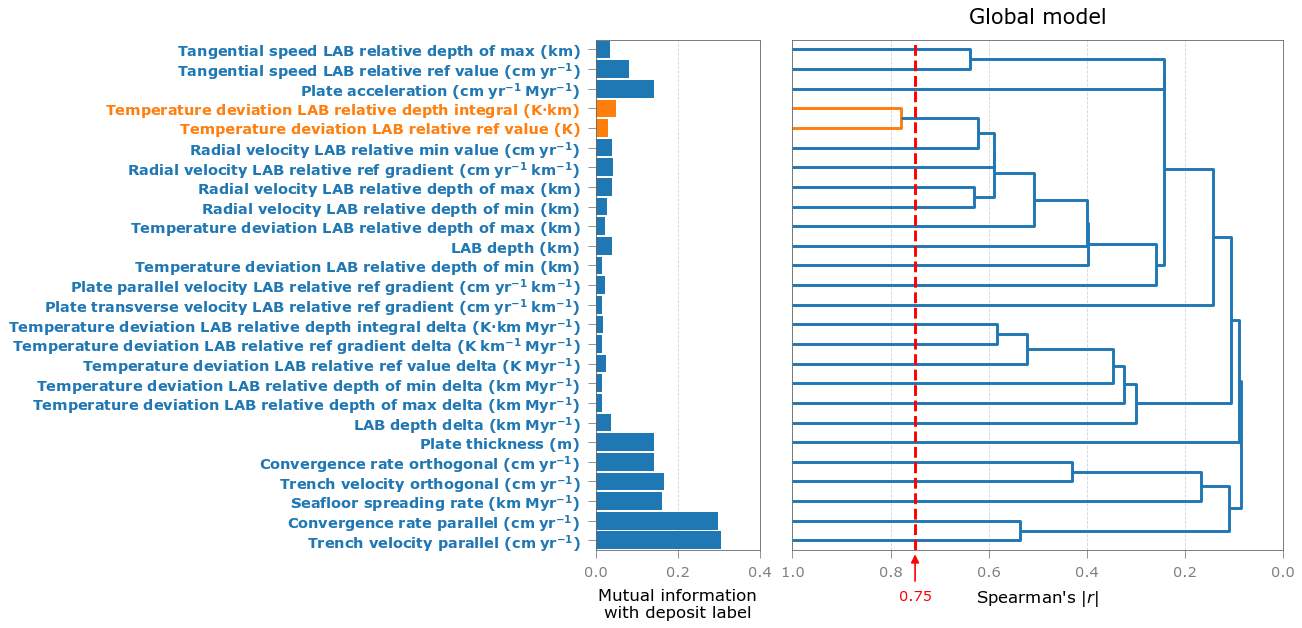

In [23]:
combined_selected_filename = figures_dir / "mi_dendrogram_selected"

plot_combined(Z, clusters, mi_series, x_pu_sel.columns, title="Global model", filename=combined_selected_filename)

In [ ]:
with open(selected_features_manifest_filepath) as f:
    selected_manifest = json.load(f)

plot_combined(Z, clusters, mi_series, x_pu_sel.columns, title="Global model",
              filename=figures_dir / "mi_dendrogram_selected_feature_sets",
              feature_set_map=selected_manifest)

## Select regional features

#### Feature analysis

In [ ]:
clusters_regions = {region: None for region in data_regional["region"].unique()}
mi_series_regions = {}

In [ ]:
clusters_regions = {region: None for region in data_regional["region"].unique()}
mi_series_regions = {}
if create_regional_models:
    for region, subset in data_regional.groupby("region"):
        region = str(region)
        if (subset["label"] == "positive").sum() < 50:
            print(f"Skipping region: {region}")
            continue
        subset = subset.drop(
            columns=list(columns_to_drop),
            errors="ignore",
        )
        r = "_".join(region.lower().split())

        print(f"Region: {region}")
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]
        print(subset.groupby("label").size())
        x_pu_subset = subset.drop(columns="label")
        y_pu_subset = subset["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")
        preprocessing_subset = clone(preprocessing).fit(x_pu_subset)
        fnames_subset = preprocessing_subset.get_feature_names_out()
        X_preprocessed_subset = preprocessing_subset.transform(x_pu_subset)

        # Perform hierarchical clustering on features
        Z_subset = linkage(
            X_preprocessed_subset.T,
            method="single",
            metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
        )

        cluster_ids_subset = fcluster(Z_subset, cluster_threshold, criterion="distance")
        clusters_subset = {
            cluster_id: list(fnames_subset[cluster_ids_subset == cluster_id])
            for cluster_id in np.unique(cluster_ids_subset)
        }
        clusters_regions[region] = clusters_subset

        # Compute MI scores with target for each feature
        mi_scores_subset = mutual_info_classif(
            X_preprocessed_subset,
            y_pu_subset,
            random_state=random_seed,
        )
        p_subset = y_pu_subset.mean()
        mi_normalised_subset = mi_scores_subset / scipy_entropy([p_subset, 1 - p_subset])
        mi_series_regions[region] = pd.Series(mi_normalised_subset, index=fnames_subset)

        # Combined dendrogram and MI bar chart
        mi_dendrogram_filename_subset = figures_dir / f"mi_dendrogram_{r}"
        plot_combined(Z_subset, clusters_subset, mi_series_regions[region], fnames_subset, title=f"{region} model", filename=mi_dendrogram_filename_subset)

        # Cutoff vs. number of features
        thresh_clusters_subset = np.array([
            len(np.unique(fcluster(Z_subset, 1 - t, criterion="distance")))
            for t in thresh_vals
        ])

        cutoff_nfeatures_filename_subset = figures_dir / f"cutoff_nfeatures_{r}"
        fig, ax = plt.subplots()
        ax.step(thresh_vals, thresh_clusters_subset, where="post")
        ax.axvline(
            cutoff_value,
            linestyle="dashed",
            color="red",
            zorder=10,
            label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters_subset)} features)",
        )
        ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
        ax.set_ylim(0, None)
        ax.grid(linestyle="dashed", color="lightgrey")
        ax.legend(loc="best")
        ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
        ax.set_ylabel("Number of remaining features")
        ax.set_title(f"{region} model")

        for ext in (".pdf", ".png"):
            fig.savefig(f"{cutoff_nfeatures_filename_subset}{ext}", dpi=350, bbox_inches="tight")

In [71]:
if create_regional_models:
    for region, clusters_subset in clusters_regions.items():
        print(f"{region}:")
        for cluster_id in sorted(clusters_subset.keys()):
            print(f"  Cluster #{cluster_id}:")
            for f in clusters_subset[cluster_id]:
                print(f"    - {f}")

East Asia:
  Cluster #1:
    - convergence_obliquity (degrees)
    - convergence_rate_parallel (cm/yr)
  Cluster #2:
    - subducting_plate_absolute_obliquity (degrees)
    - subducting_plate_absolute_velocity_parallel (cm/yr)
  Cluster #3:
    - trench_velocity_parallel (cm/yr)
  Cluster #4:
    - trench_velocity_obliquity (degrees)
  Cluster #5:
    - arc_trench_distance (km)
    - slab_dip (degrees)
  Cluster #6:
    - seafloor_age (Ma)
  Cluster #7:
    - slab_flux (m^2/yr)
  Cluster #8:
    - subducting_plate_absolute_velocity_orthogonal (cm/yr)
  Cluster #9:
    - trench_velocity_orthogonal (cm/yr)
  Cluster #10:
    - distance_to_trench_edge (km)
  Cluster #11:
    - distance_from_trench_start (km)
  Cluster #12:
    - 1000k_isotherm_depth_delta (km/timestep)
    - sublithospheric_cold_anomaly_thickness_delta (km/timestep)
    - cold_anomaly_magnitude_delta (K/timestep)
  Cluster #13:
    - temperature_deviation_avg_0-400km_rolling_30ma (K)
    - temperature_deviation_avg_0-400k

#### Select features

In [ ]:
regions = data_regional["region"].unique()
if create_regional_models:
    if use_same_features:
        print("Using same features for all models")
        selected_features_regions = {
            region: selected_features
            for region in clusters_regions.keys()
        }
    elif automatic_feature_selection:
        selected_features_regions = {
            region: [
                max(clusters_regions[region][i], key=lambda f: mi_series_regions[region].get(f, 0.0))
                for i in sorted(clusters_regions[region].keys())
            ]
            for region in clusters_regions.keys()
        }
    else:
        selected_features_regions = {
            "North America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_min (m)",
                "trench_velocity_orthogonal (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_dip (degrees)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "total_water_thickness (m)",
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "South America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_orthogonal (cm/yr)",
                "sediment_thickness (m)",
                "convergence_rate_parallel (cm/yr)",
                "slab_dip (degrees)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "distance_to_trench_edge (km)",
                "seafloor_spreading_rate (km/Myr)",
                "crustal_thickness_min (m)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
            ],
            "Southeast Asia": [
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "slab_dip (degrees)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_median (m)",
                "crustal_thickness_min (m)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_orthogonal (cm/yr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "Tethys": [
                "convergence_rate_parallel (cm/yr)",
                "convergence_obliquity (degrees)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "subducting_plate_absolute_obliquity (degrees)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "distance_to_trench_edge (km)",
                "crustal_thickness_mean (m)",
                "slab_dip (degrees)",
                "sediment_thickness (m)",
                "crustal_thickness_min (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_orthogonal (cm/yr)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench (km)",
            ]
        }
for region, features in selected_features_regions.items():
    region_filename = f"{selected_features_filepath.stem}_{region.lower().replace(' ', '_')}.csv"
    pd.DataFrame({"selected_features": features}).to_csv(
        selected_features_filepath.with_name(region_filename),
        index=False,
    )

## Bonus

#### Mutual info with other features
To determine whether our features are truly independent, we compare their mutual information, i.e., "how much does each of these features tell you about each of the other features?"

**Note:** These cells run mutual information for every feature with every single other feature: it will take a while.

In [ ]:
plot_bonus = True

In [ ]:
plot_regression_MI = True

In [ ]:
if plot_regression_MI:
    features = x_pu.columns
    n = len(features)

    rows = joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(mutual_info_regression)(x_pu, x_pu[col], random_state=random_seed)
        for col in features
    )
    mi_matrix = np.array(rows)

    # Symmetrise — should be symmetric in theory but kNN estimates introduce asymmetry
    mi_matrix = (mi_matrix + mi_matrix.T) / 2

    # Zero the diagonal before normalising (self-MI is uninformative here)
    np.fill_diagonal(mi_matrix, 0)

    # Normalise each row by H(target feature) so cell [i,j] = I(X_j; X_i) / H(X_i):
    # fraction of uncertainty in feature i explained by feature j.
    # differential_entropy can be negative for very concentrated distributions;
    # clip to [0, 1] as a safeguard against those edge cases.
    X_arr = clone(preprocessing).fit_transform(x_pu).values
    entropies = np.array([differential_entropy(X_arr[:, i]) for i in range(n)])
    with np.errstate(divide="ignore", invalid="ignore"):
        mi_matrix = np.where(
            entropies[:, np.newaxis] > 0,
            mi_matrix / entropies[:, np.newaxis],
            0.0,
        )
    mi_matrix = np.clip(mi_matrix, 0, 1)

    mi_df = pd.DataFrame(mi_matrix, index=features, columns=features)
    mi_df.to_csv(figures_dir / "mutual_information_matrix.csv")

    # Build linkage from MI distance (1 - MI) so the dendrogram clusters by
    # pairwise MI directly, rather than Euclidean distance between MI profiles.
    from scipy.spatial.distance import squareform
    mi_dist = 1 - mi_df.values
    np.fill_diagonal(mi_dist, 0)
    Z_mi = linkage(squareform((mi_dist + mi_dist.T) / 2), method="average")

In [ ]:
if plot_regression_MI:
    g = sns.clustermap(
        mi_df,
        row_linkage=Z_mi,
        col_linkage=Z_mi,
        cmap="viridis",
        vmin=0, vmax=1,
        annot=False,
        figsize=(15, 15),
        xticklabels=True,
        yticklabels=True,
        cbar_kws={"label": "I(X_j ; X_i) / H(X_i)", "location": "bottom", "shrink": 0.8}
    )
    g.ax_cbar.set_position([0.8, 0.1, 0.1, 0.02])

    for ext in (".pdf", ".png"):
        fig.savefig(f"{figures_dir / "regression_mi"}{ext}", dpi=350, bbox_inches="tight")